In [33]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 設定中文字體，解決中文顯示問題
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']  # 設定字體
plt.rcParams['axes.unicode_minus'] = False  # 解決負號顯示問題

In [34]:
# 1. 準備資料
stock_id = "2330.TW"
print(f"機器人正在分析 {stock_id} 的走勢...")
stock = yf.Ticker(stock_id)
df = stock.history(period="1y") # 抓一年資料

機器人正在分析 2330.TW 的走勢...


In [35]:
# 2. 計算均線 (Moving Average)
# 這裡我們用 MA5 (週線) 和 MA20 (月線) 來做短線交易
df['MA5'] = df['Close'].rolling(window=5).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()

In [ ]:
# 3. 找出 "交叉點" (核心邏輯！)
# 黃金交叉條件：今天 MA5 > MA20 且 昨天 MA5 < MA20
# 我們用 shift(1) 拿到 "昨天" 的數據
df['Prev_MA5'] = df['MA5'].shift(1)
df['Prev_MA20'] = df['MA20'].shift(1)

# 產生訊號 (Signal)：符合條件設為 True
df['Golden_Cross'] = (df['MA5'] > df['MA20']) & (df['Prev_MA5'] < df['Prev_MA20'])

# 為了讓老闆看清楚，我們把發生黃金交叉那天的資料印出來
buy_signals = df[df['Golden_Cross']]
print(f"\n--- 發現 {len(buy_signals)} 次黃金交叉訊號！ ---")
print(buy_signals[['Close', 'MA5', 'MA20']].tail()) # 印出最近幾次, 預設為5次


--- 發現 6 次黃金交叉訊號！ ---
                                 Close          MA5         MA20
Date                                                            
2025-06-09 00:00:00+08:00   993.454834   976.254761   968.396094
2025-08-29 00:00:00+08:00  1151.539917  1162.459741  1157.496252
2025-09-09 00:00:00+08:00  1191.248291  1167.423291  1161.467059
2025-12-04 00:00:00+08:00  1440.199341  1430.232568  1429.734241
2025-12-24 00:00:00+08:00  1495.000000  1462.000000  1453.833063


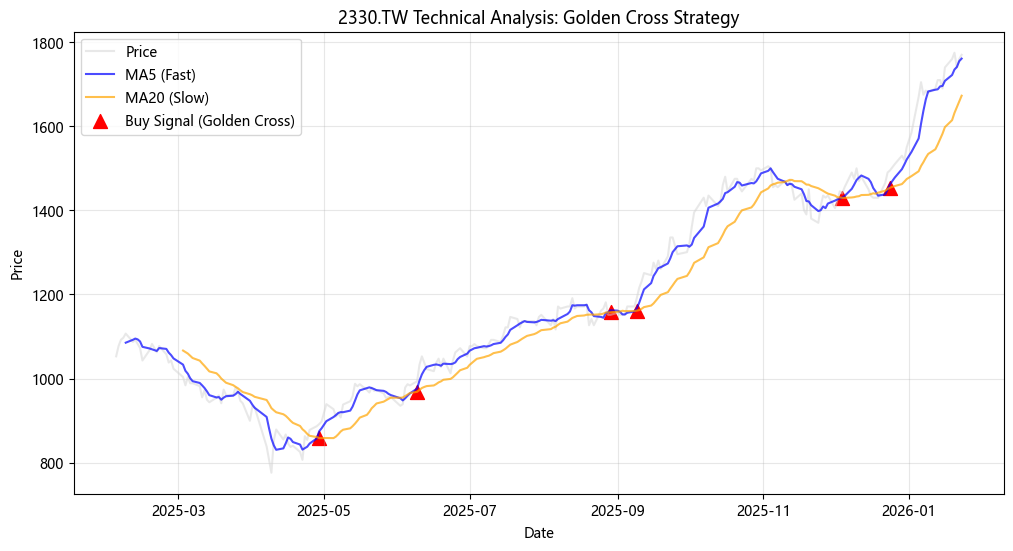


分析圖表已產生！請查看紅色三角形標記。


In [37]:
# 4. 畫圖驗收
plt.figure(figsize=(12, 6))

# 畫股價與均線
plt.plot(df.index, df['Close'], label='Price', color='lightgray', alpha=0.5)
plt.plot(df.index, df['MA5'], label='MA5 (Fast)', color='blue', alpha=0.7)
plt.plot(df.index, df['MA20'], label='MA20 (Slow)', color='orange', alpha=0.7)

# 畫出買進訊號 (紅色三角形)
# 只畫在有黃金交叉的那一天
plt.scatter(buy_signals.index, buy_signals['MA20'], 
            color='red', marker='^', s=100, label='Buy Signal (Golden Cross)')

plt.title(f'{stock_id} Technical Analysis: Golden Cross Strategy')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
# plt.savefig('golden_cross_bot.png')
plt.show()

print("\n分析圖表已產生！請查看紅色三角形標記。")